# Lab 1 — Multi‑Armed Bandits (ε‑Greedy, Bernoulli Rewards)



In this lab you will:

1. Implement a Bernoulli K-armed bandit environment.

2. Implement the $\varepsilon$-greedy action-selection strategy.

3. Compare performance for different values of $\varepsilon$ (average reward, optimal-action rate, cumulative regret).

4. Compare computation time of two update methods for estimating action values:

   - Naive sample mean: recompute the mean from *all* past rewards for that arm each time (memory heavy).
   
   - Incremental sample mean: constant-time update using the running average and sample size $n$.
   
   
**Bandit model.**

- Each arm i has a fixed but unknown success probability $p_i$ (drawn from the probability distribution $\mathcal{U}(0,1)$).

- Pulling arm i yields reward $R\in\{0,1\}$ with $\mathbb{P}(R=1)=p_i$  (Bernoulli).


## Setup

In [197]:
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Environment: Bernoulli K‑armed bandit

We first use a class to define a bandit environment, which is an object that knows its arms and can produce rewards.

-------

What is a class in Python ? A class in Python is like a template for creating objects that have:
1. some data (variables),
2. and some behaviors (functions called methods).

-------

**Exercise 1.** Read the following cell and learn how we define the Bernoulli Bandit environment.

In [198]:
MIN_ARMS = 2  # Minimum number of arms


class BernoulliBanditK:
    """K-armed Bernoulli bandit environment.

    - We have K arms (slot machines).
    - Each arm i has a hidden success probability p_i (drawn from Uniform(0,1)).
    - When we pull arm i, we get a reward R that is either 0 or 1.
        - P(R=1) = p_i
        - P(R=0) = 1 - p_i
    """

    # -----------------------------------------------------------
    # __init__ : runs automatically when we create the object
    # -----------------------------------------------------------

    def __init__(self, k: int = 10) -> None:
        """Initialize (create) a new bandit environment.

        Parameters
        ----------
        k : int
            Number of arms (default 10).

        """
        # A safety check: we need at least 2 arms.
        assert k >= MIN_ARMS, "Use at least 2 arms."

        # 'self' refers to this particular object we are creating.
        self.k = k  # store the number of arms inside the object

        # Generate the true success probabilities of each arm.
        # Each p_i is drawn from a Uniform(0,1) distribution.
        self.p = np.random.uniform(low=0.0, high=1.0, size=k)

        # After this, the bandit is ready to use! Think of self as “this bandit”.

    # -----------------------------------------------------------
    # pull:
    # When you pull an arm i, it gets reward = 1 with probability p_i,
    # -----------------------------------------------------------

    def pull(self, arm: int) -> int:
        """Simulate pulling one of the K arms.

        Returns reward = 1 with probability p[arm], otherwise 0.
        """
        # np.random.rand() generates a random number in [0,1).
        # If it's smaller than p[arm], we count it as a success (reward=1).
        return int(np.random.rand() < self.p[arm])  # here it gives a “manual Bernoulli”

    # -----------------------------------------------------------
    # optimal_arm :
    # gives the index of the largest element in self.p,
    # and it tells us which arm is truly best.
    # (This is for evaluation only — the learning agent can’t see this.)
    # -----------------------------------------------------------

    def optimal_arm(self) -> int:
        """Index of the true best arm (largest p_i)."""
        return int(np.argmax(self.p))

    # -----------------------------------------------------------
    # optimal_mean :
    # gives the largest p_i
    # This is useful for computing regret, i.e.
    # how much worse the agent’s reward is compared to always choosing the best arm.
    # -----------------------------------------------------------

    def optimal_mean(self) -> float:
        """Mean reward of the true best arm (largest p_i)."""
        return float(np.max(self.p))

    # -----------------------------------------------------------
    # __repr__ is another special method (like __init__). #repr stands for "representation."
    # It controls what happens when you type the object name or print it:
    # -----------------------------------------------------------

    def __repr__(self) -> str:
        """Return string representation of the bandit."""
        return f"BernoulliBanditK(k={self.k}, p={np.array2string(self.p, precision=3)})"

**Exercise 2.** Run the following cell and observe its output.


In [199]:
env = BernoulliBanditK(k=5)
print(env)  # show the bandit's true probabilities
print("Best arm:", env.optimal_arm())  # in [0,1,2,3,..., k-1]
print("Best success prob:", env.optimal_mean())
print("Reward from arm 2 for one pull:", env.pull(2))

BernoulliBanditK(k=5, p=[0.79  0.49  0.023 0.542 0.146])
Best arm: 0
Best success prob: 0.789755294314211
Reward from arm 2 for one pull: 0


## ε-Greedy algorithm for action selection


In reinforcement learning, the **ε-greedy strategy** is one of the simplest methods to balance the exploration–exploitation trade-off.

- **Exploitation:** choose the action (or arm) with the current highest estimated value  
  $\rightarrow$ use what you know to get the best immediate reward.
- **Exploration:** with a small probability ε, choose a random action  
  $\rightarrow$ try something new to discover potentially better options.

Formally, for a set of estimated action values $Q(a)$:

$$
A_t =
\begin{cases}
\text{a random action}, & \text{with probability } \varepsilon, \\
\arg\max_a Q(a), & \text{with probability } 1 - \varepsilon.
\end{cases}
$$

### Algorithm steps
1. Generate a random number $u \sim \text{Uniform}(0,1)$.
2. If $u < \varepsilon$: **explore** $\rightarrow$ select a random arm.
3. Otherwise: **exploit** $\rightarrow$ select any arm with the largest estimated value $ Q(a) $.
4. In case of ties (several arms with the same maximum value), choose uniformly at random among them.

### Typical choices
- Small $\varepsilon$ values (e.g., 0.01 or 0.1) $\rightarrow$ mostly exploitation, little exploration.
- Large $\varepsilon$ values (e.g., 0.3 or 0.5) $\rightarrow$ more exploration, slower convergence.
- Sometimes we can choose $\varepsilon$ which decreases over time ($\varepsilon$-decay): explore more at the beginning, exploit more later.


-------------------


**Exercise 3.** Define a function called `select_action_eps_greedy` that takes as input the estimated action values `Q` and the exploration rate `epsilon`, and returns the index of the selected arm.


In [200]:
def select_action_eps_greedy(Q: np.ndarray, epsilon: float) -> int:
    """Select an action according to the ε-greedy strategy.

    With probability ε: explore (choose a random arm).
    With probability 1-ε: exploit (choose an arm uniformly with the highest estimated value).

    Parameters
    ----------
    Q : array of shape (k,)
        Current estimated values of each arm.
    epsilon : float
        Exploration probability ε in [0, 1].

    Returns
    -------
    action : int
        The index of the selected arm.

    """
    # First, with probability ε: explore (choose a random arm).
    if np.random.rand() < epsilon:
        return np.random.randint(len(Q))

    # With probability 1−ε: exploit (choose an arm with the highest estimated value).
    max_val = np.max(
        Q,
    )  # Compute the maximum value of the array Q and store it in the variable max_val
    candidates = np.isclose(
        Q,
        max_val,
    )  # (see Hint) Find all positions in Q where the value equals max_val.

    return np.random.choice(
        candidates,
    )  # pick one of those best arms uniformly at random.

*Hint for Exercise 3 (Part 1):* We can not use `np.argmax(Q)` here, because it only gives the first index with the maximum value in $Q$.

In [201]:
Q_example = np.array([0.3, 0.5, 0.5, 0.2])
print(np.argmax(Q_example))

1


*Hint for Exercise 3 (Part 2):* However, if we use the following expression, it returns all the indices of the maximum value in $Q$. 


In [202]:
# Find the maximum estimated value
max_val = np.max(Q_example)

# Compare each Q[i] with the maximum (returns True/False)
is_best = np.isclose(Q_example, max_val)

# Extract the indices where the value is close to the maximum
candidates = np.where(is_best)[0]

print(candidates)

[1 2]


*Hint for Exercise 3 (Part 3):* Note: Why do we use `np.isclose()` instead of `Q_example == max_val`?

Because of floating-point rounding errors. For example:

In [203]:
Q_example = np.array([0.1 + 0.2, 0.3])
Q_example == np.max(Q_example)

array([ True, False])

*Hint for Exercise 3 (Part 4):* It gives `array([ True, False])` even though both numbers should be equal mathematically (0.3 vs 0.30000000000000004). 

So `np.isclose()` is safer — it allows for tiny numerical differences due to rounding.

## Two ways to estimate action reward $Q_i$

To decide which arm to pull, the agent maintains an estimate $ Q_i $ of the expected reward for each arm $ i $.  
After each pull, this estimate must be updated using the new observed reward.

There are two common approaches to update the action-value estimates:

### Notation

- $ Q_i $: the estimated average reward of arm $ i $.  



- $ R_t^{(i)}$: the reward received at time step $ t $ when arm $i $ is pulled.  
  Each time we play arm $ i $, we observe a random reward $ R_t^{(i)} $ drawn from the arm’s underlying reward distribution.


- $ N_i $: the number of times arm $ i $ has been selected so far (up to the current time t).  



### Method 1 - Naive sample mean update
- Keep all past rewards for each arm.
- Recompute the mean from all past rewards after each new observation.
  $$
  Q_i = \frac{1}{N_i}\sum_{t=1}^{N_i} R_t^{(i)}
  $$
- Conceptually simple, but inefficient:
  - requires storing all past rewards,
  - recomputes the average each time (O(N) per update).

### Method 2 - Incremental update
- Keep only the **current average** and the **number of times** an arm was selected.
- Update the estimate using the new reward $ R_t $ with a single formula:
  $$
  Q_i \leftarrow Q_i + \frac{1}{N_i}\big(R_t - Q_i\big)
  $$
- Much faster and memory-efficient (O(1) per update).


Both approaches give  the same result mathematically, but the incremental one is preferred in practice.

-----------------------------------

**Exercise 4.** Write a function called `update_naive` that takes as input the list of rewards for each arm `lists_of_rewards`, the selected arm index `a`, the received reward `r`, and the array of estimated values `Q`, and updates `Q[a]` with Method 1 Naive update. 


*Hint.* Method 1: Naive update: `update_naive(...)`

`lists_of_rewards` is a Python list of length $K$, where each element stores all past rewards obtained from that arm.


When we receive a new reward $r$ from arm $a$, we append it to that arm’s list.
Then, we recompute the average of all past rewards for that arm and store it in `Q[a]` as the new estimate of its action value.



In [204]:
def update_naive(lists_of_rewards, a: int, r: float, Q: np.ndarray) -> None:
    """Update the action-value estimate Q[a] using the new reward r."""
    lists_of_rewards[a].append(r)
    Q[a] = np.mean(lists_of_rewards[a])


----------------


**Exercise 5.** Write a function called `update_incremental` that takes as input the array of estimated values `Q`, the array of counts `N`, the selected arm index `a`, and the received reward `r`, and updates `Q[a]` incrementally using the new reward by Method 2 Incremental update.

*Hint.* Method 2: Incremental update: `update_incremental(...)`

Instead of storing all past rewards, we can update each estimate $Q_i$ incrementally using only the most recent reward.  
This method keeps a running average that gradually incorporates new information.  
It requires only two arrays:
- `Q`: current estimated values of each arm  
- `N`: the number of times each arm has been selected  

Each time we observe a new reward $r $ from arm $ a $,  we increase its count `N[a]` and update the estimate `Q[a]` using a simple formula derived from the sample mean.



In [205]:
def update_incremental(Q: np.ndarray, N: np.ndarray, a: int, r: float) -> None:
    """Incremental update of the action-value estimate Q[a] using the new reward r."""
    N[a] += 1
    Q[a] += (r - Q[a]) / N[a]

## Running one ε‑greedy experiment (single run)


In this section, we simulate *one complete ε-greedy experiment* on the Bernoulli bandit environment.  
The function `run_once()` runs the agent for **T time steps**, using a given exploration rate $\varepsilon$ and a chosen update method (either `"naive"` or `"incremental"`).


At each time step:


1. The agent selects an arm using the $\varepsilon$-greedy strategy.  


2. It pulls that arm and receives a reward from the environment.  


3. The corresponding action value $Q_a$ is updated using the chosen update rule.  


4. We record:


- the obtained reward,
   
   
- whether the optimal arm was selected,
   

- and the *regret at each step*, which measures how much reward the agent missed compared to always choosing the best arm:
   
$$\text{regret}_t = p^* - R_t,$$
     
where $ p^* $ is the true mean of the best arm.


The function returns all recorded results (rewards, regret, and optimal-action indicators) in a dictionary,  
so we can later compute averages and visualize learning performance.




In [206]:
def run_once(T: int, epsilon: float, k: int = 10, update_style: str = "incremental"):
    """Run one full experiment of T time steps using ε-greedy on a k-armed Bernoulli bandit.

    Args:
        T (int): number of steps in this run
        epsilon (float): exploration probability for ε-greedy
        k (int, optional): number of arms. Defaults to 10.
        update_style (str, optional): "incremental" (default) or "naive" to choose the update rule.

    Returns:
        dict: results of the run

    """
    env = BernoulliBanditK(k=k)  # Create a new bandit environment with k arms.

    # For evaluation only (not used by the agent),
    opt_arm = (
        env.optimal_arm()
    )  # the index of the truly best arm which has the largest p_i
    opt_mean = env.optimal_mean()  # the best true success probability p_i

    if hasattr(opt_mean, "item"):
        opt_mean = opt_mean.item()

    # -------------------------------------------------
    # Initialize the action-value estimates Q_i to 0 for all arms.
    Q = np.zeros(k, dtype=float)

    # record what happens at each time step
    rewards = np.zeros(
        T,
        dtype=float,
    )  # rewards[t] = observed reward at step t (0 or 1),
    chose_opt = np.zeros(
        T,
        dtype=float,
    )  # chose_opt[t] = 1 if the chosen arm equals opt_arm, else 0,
    regret = np.zeros(
        T,
        dtype=float,
    )  # regret[t]=p^*-R_t, which means how much we “missed” compared to the best arm

    # -------------------------------------------------
    # For the naive method,
    # we keep all past rewards per arm in lists,
    # so we can recompute the average from the full history each time.
    # -------------------------------------------------

    # Initialisation pour la méthode naive
    reward_lists = [[] for _ in range(k)] if update_style == "naive" else None
    # Initialisation pour la méthode incrémentale
    N = np.zeros(k, dtype=int) if update_style != "naive" else None

    for t in range(T):
        if np.random.rand() < epsilon:
            a = np.random.randint(k)
        else:
            max_val = np.max(Q)
            candidates = np.where(np.isclose(Q, max_val))[0]
            a = np.random.choice(candidates)
        # ---------------------------------------------------------------------------------------
        raw_reward = env.pull(a)
        r = raw_reward.item() if hasattr(raw_reward, "item") else raw_reward

        rewards[t] = r
        chose_opt[t] = 1.0 if a == opt_arm else 0.0
        regret[t] = opt_mean - r

        if update_style == "naive":
            update_naive(reward_lists, a, r, Q)
        else:
            update_incremental(Q, N, a, r)

    return {
        "p": env.p,
        "optimal_arm": opt_arm,
        "optimal_mean": opt_mean,
        "rewards": rewards,
        "optimal_selected": chose_opt,
        "regret": regret,
    }


# for the return part, we package all useful outputs in a dictionary:
# p: the true probabilities
# optimal_*: the true values for evaluation,
# rewards, optimal_selected, regret: per-step logs we will average/plot later.

## Averaging curves over many random runs

In a single $\varepsilon$-greedy run, the results depend on random factors such as the sampled arm probabilities and the random exploration choices.  
To obtain *smooth and reliable performance curves*, we repeat the experiment many times  
and average the results over all runs.


-------------------



**Exercise 6.** Write a function called `run_many` that takes as input the number of runs `runs`, the number of time steps per run `T`, the exploration rate `epsilon`, the number of arms `k`, and the update rule `update_style` ("incremental" or "naive"). The function should return the average reward, the average rate of optimal action selection, and the average cumulative regret across all runs.


*Hint.* The function `run_many()` performs this averaging process:

1. It runs the same experiment (`run_once`) several times (given by `runs`).

2. For each time step, it accumulates:

   - the average reward,
   
   - the probability of selecting the optimal arm,
   
   - and the cumulative regret (sum of regrets up to that point).
   
3. Finally, it divides the totals by the number of runs to get the mean curves.

The returned arrays represent the *average learning behavior* of the $\varepsilon$-greedy agent across many independent experiments.


In [207]:
def run_many(
    runs: int,
    T: int,
    epsilon: float,
    k: int,
    update_style: str = "incremental",
):
    """Run multiple independent experiments of T time steps using ε-greedy on a k-armed Bernoulli bandit.

    Args:
        runs (int): number of independent repetitions of the full experiment
        T (int): number of steps in each run
        epsilon (float): exploration probability for ε-greedy
        k (int): number of arms
        update_style (str): "incremental" (default) or "naive" to choose the update rule

    """
    results = []
    for _run in range(runs):
        res = run_once(T, epsilon, k, update_style)
        results.append(res)

    avg_rewards = np.mean([res["rewards"] for res in results], axis=0)
    avg_optimal = np.mean([res["optimal_selected"] for res in results], axis=0)
    avg_instant_regret = np.mean([res["regret"] for res in results], axis=0)

    return avg_rewards, avg_optimal, np.cumsum(avg_instant_regret)

-------------------


## Experiment 1 — $\varepsilon$ comparison (incremental updates)


This section runs the $\varepsilon$ -greedy algorithm with different exploration rates ($\varepsilon$) and compares their performance.
It shows how $\varepsilon$  affects learning by plotting:

1. the average reward over time,

2. the probability of selecting the optimal arm,

3. the average cumulative regret.

The goal is to visualize the exploration–exploitation trade-off.

**Question : Which ε gives the best performance overall, and why?**

In [208]:
K = 10  # number of arms in the bandit.
T = 1000  # number of time steps per experiment.
RUNS = 300  # number of independent runs to average results
eps_list = [0.0, 0.01, 0.1, 0.3]  # list of epsilon values to test.

# ----------------------------------------------

# For each epsilon:
# Call run_many() to perform 300 averaged runs of epsilon-greedy with that epsilon value.
# Store the resulting averaged curves in a dictionary:
# "avg_reward" : average reward per step,
# "avg_opt" : probability of selecting the optimal arm,
# "avg_cumreg" : average cumulative regret.

results = {}
for eps in eps_list:
    ar, ao, cr = run_many(runs=RUNS, T=T, epsilon=eps, k=K, update_style="incremental")
    results[eps] = {"avg_reward": ar, "avg_opt": ao, "avg_cumreg": cr}

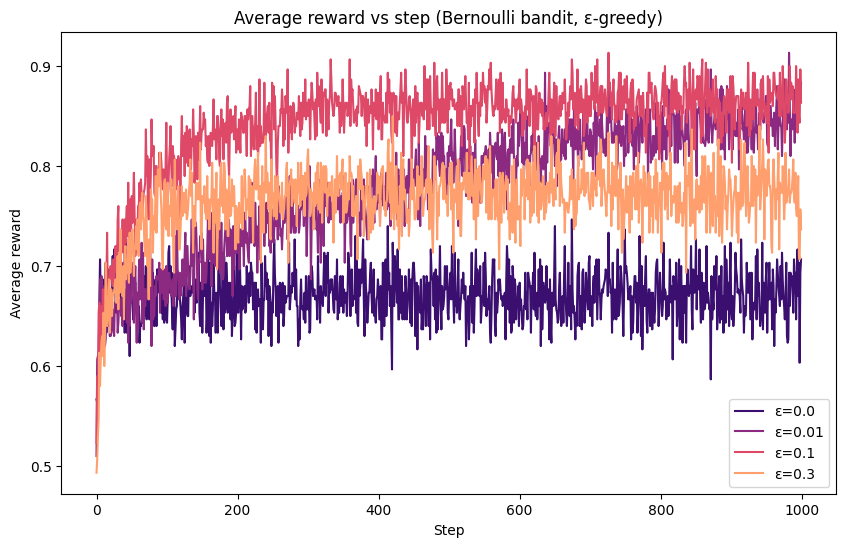

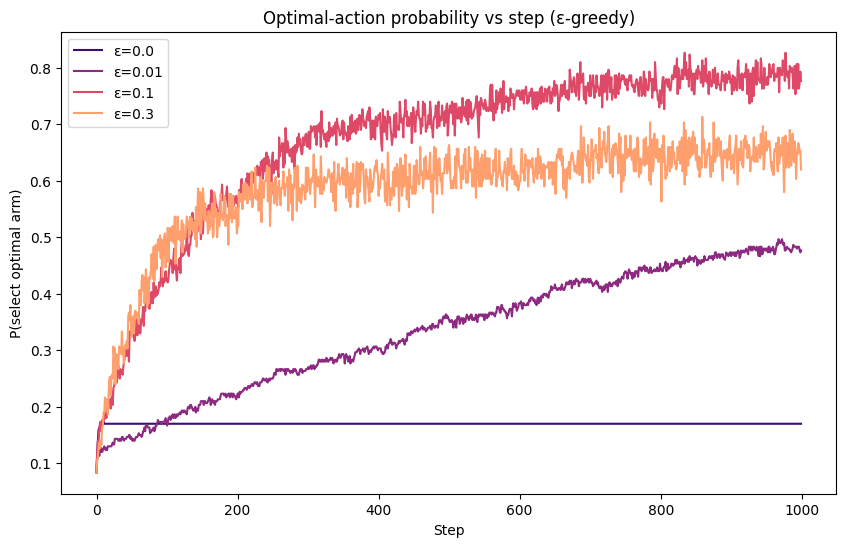

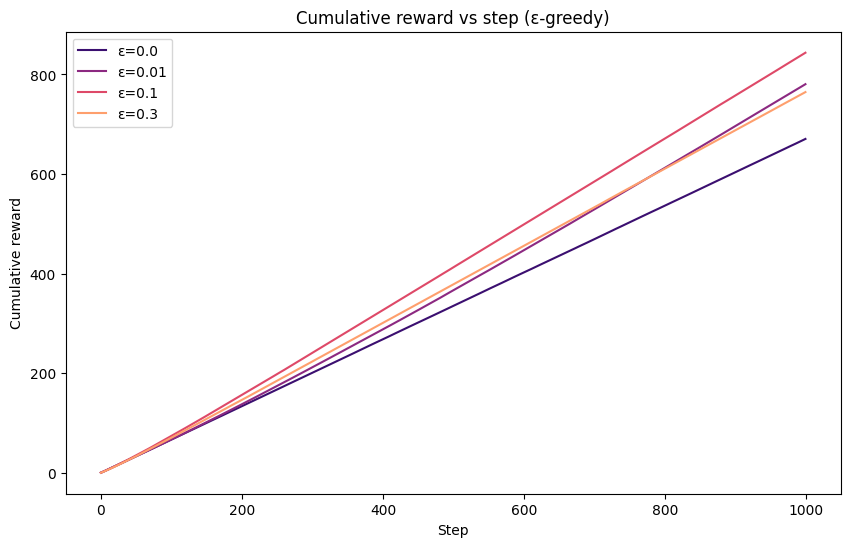

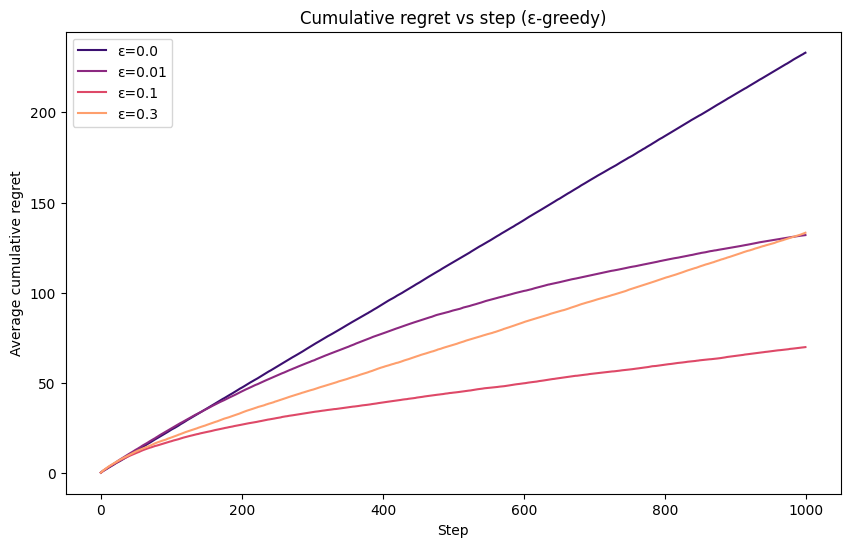

In [209]:
# Plot: Average reward
colors = sns.color_palette("magma", len(eps_list))

plt.figure(figsize=(10, 6))
for eps in eps_list:
    plt.plot(
        results[eps]["avg_reward"],
        label=f"ε={eps}",
        color=colors[eps_list.index(eps)],
    )
plt.xlabel("Step")
plt.ylabel("Average reward")
plt.title("Average reward vs step (Bernoulli bandit, ε-greedy)")
plt.legend()
plt.show()

# Plot: Probability of optimal action
plt.figure(figsize=(10, 6))
for eps in eps_list:
    plt.plot(
        results[eps]["avg_opt"],
        label=f"ε={eps}",
        color=colors[eps_list.index(eps)],
    )
plt.xlabel("Step")
plt.ylabel("P(select optimal arm)")
plt.title("Optimal-action probability vs step (ε-greedy)")
plt.legend()
plt.show()

# Plot: Cumulative rewards vs step
plt.figure(figsize=(10, 6))
for eps in eps_list:
    cum_rewards = np.cumsum(results[eps]["avg_reward"])
    plt.plot(cum_rewards, label=f"ε={eps}", color=colors[eps_list.index(eps)])

plt.xlabel("Step")
plt.ylabel("Cumulative reward")
plt.title("Cumulative reward vs step (ε-greedy)")
plt.legend()
plt.show()


# Plot: Cumulative regret
plt.figure(figsize=(10, 6))
for eps in eps_list:
    plt.plot(
        results[eps]["avg_cumreg"],
        label=f"ε={eps}",
        color=colors[eps_list.index(eps)],
    )
plt.xlabel("Step")
plt.ylabel("Average cumulative regret")
plt.title("Cumulative regret vs step (ε-greedy)")
plt.legend()
plt.show()

###  Discussion: Which ε gives the best performance overall?

In [196]:
# Calculate final performance metrics for each epsilon
print("### Performance Summary for Different ε Values\n")
print(
    f"{'ε':<6} {'Final Avg Reward':<18} {'Final Opt %':<15} {'Final Cum Reward':<18} {'Final Cum Regret':<18}",
)
print("-" * 80)

for eps in eps_list:
    final_avg_reward = results[eps]["avg_reward"][-1]
    final_opt_prob = results[eps]["avg_opt"][-1] * 100
    final_cum_reward = np.cumsum(results[eps]["avg_reward"])[-1]
    final_cum_regret = results[eps]["avg_cumreg"][-1]

    print(
        f"{eps:<6.2f} {final_avg_reward:<18.4f} {final_opt_prob:<15.2f} {final_cum_reward:<18.2f} {final_cum_regret:<18.2f}",
    )

# Find the best epsilon based on multiple criteria
best_eps_reward = max(eps_list, key=lambda e: results[e]["avg_reward"][-1])
best_eps_opt = max(eps_list, key=lambda e: results[e]["avg_opt"][-1])
best_eps_cumrew = max(eps_list, key=lambda e: np.cumsum(results[e]["avg_reward"])[-1])
best_eps_regret = min(eps_list, key=lambda e: results[e]["avg_cumreg"][-1])

print("\n### Best ε by Criterion:")
print(f"  - Highest final average reward: ε = {best_eps_reward}")
print(f"  - Highest optimal action rate: ε = {best_eps_opt}")
print(f"  - Highest cumulative reward: ε = {best_eps_cumrew}")
print(f"  - Lowest cumulative regret: ε = {best_eps_regret}")

### Performance Summary for Different ε Values

ε      Final Avg Reward   Final Opt %     Final Cum Reward   Final Cum Regret  
--------------------------------------------------------------------------------
0.00   0.6500             21.33           662.90             252.41            
0.01   0.8433             60.33           787.93             124.65            
0.10   0.8567             73.33           844.28             67.04             
0.30   0.7567             62.67           774.21             134.00            

### Best ε by Criterion:
  - Highest final average reward: ε = 0.1
  - Highest optimal action rate: ε = 0.1
  - Highest cumulative reward: ε = 0.1
  - Lowest cumulative regret: ε = 0.1


With every criterions, we always select $\epsilon = 0.1$

-------------------


## Experiment 2 — Computation time: naive vs incremental sample mean

In this experiment, we compare the computational efficiency of the two update methods:
- the *naive update*, which recomputes the average from all past rewards each time, and  
- the *incremental update*, which adjusts the mean using only the latest reward.

Although both methods produce exactly the same estimates $ Q_i $, their computation time differs greatly.

The code below measures the total runtime of each method over many steps and reports:
- the total execution time for both methods, and  
- the speedup ratio, showing how many times faster the incremental update is compared to the naive one.


In [191]:
K = 10
T_time = 100000  # adjust based on machine
EPS = 0.1
RUNS_num = 2  # average timings


def time_runner(update_style: str) -> float:
    """Run the bandit algorithm and measure the time taken.

    Args:
        update_style (str): The update style to use ("naive" or "incremental").

    Returns:
        float: The total time taken to run the algorithm.

    """
    t0 = time.perf_counter()
    for _ in range(RUNS_num):
        _ = run_once(T=T_time, epsilon=EPS, k=K, update_style=update_style)
    t1 = time.perf_counter()
    return t1 - t0


t_naive = time_runner("naive")
t_incr = time_runner("incremental")

print(
    f"Naive sample-mean total time over {RUNS_num} runs × {T_time} steps: {t_naive:.3f} s",
)
print(
    f"Incremental sample-mean total time over {RUNS_num} runs × {T_time} steps: {t_incr:.3f} s",
)
print(f"Speedup (naive / incremental): {t_naive / t_incr:.2f}×")

Naive sample-mean total time over 2 runs × 100000 steps: 214.286 s
Incremental sample-mean total time over 2 runs × 100000 steps: 2.498 s
Speedup (naive / incremental): 85.77×



**Optional exercise**

If you’re curious to go further, try experimenting with 

1. **Optimistic Initial Values:**  
   Initialize all action-value estimates `Q[i]` with a high value (e.g., `Q0 = 2` or `5`) and set `ε = 0`.  
   Observe how the agent still explores different arms at the beginning and then focuses on the best one as estimates decrease.

2. **Upper-Confidence-Bound (UCB):**  
   Use the rule  
   $$
   A_t = \arg\max_i \Big[ Q_i(t) + c \sqrt{\tfrac{\ln t}{N_i(t)}} \Big],
   $$
   where \(c>0\) controls how much to explore.  
   Try different values of `c` (e.g., `0.5`, `1`, `2`) and compare the results with ε-greedy.

**Question:**  
How do these strategies differ from ε-greedy in terms of exploration behavior and learning speed?  
